In [5]:
from matplotlib import pyplot as plt
from functions import *

# EV and Ru(bpy)3 stock solutions were in water, may have affected buffering capacity of solution and EDTA equilibria
# mixing limitations in cuvette, colour gradient seen

# V(Ru(bpy)3, 1 mM, water) = 200 ul, V(EDTA, saturated, buffer) = 1 ml, made up to 3 ml pH 6 buffer
# V(EV, 1 mM, water) in ul used and start times for each run

root = "./results/260625_Rubpy_EV_EDTA"

XV = r"[EV$^{+\!\cdot\!}$]" # [XV+.]
XV0 = r"[EV$^{2\!+\!}$]$_0$" # [XV2+]0
peak = 600 # nm
e = 1.22e6 # M-1 m-1
l = 1e-2 # m
cstock = 1e-3 # [XV] in stock solution
vsol = 3e-3 # total volume of reaction mixture

# (volume of XV in ul, start time)
runs = [(300, "16-41-38-018"), # run on 260625
        (600, "11-51-44-531"), # run on 260629
        (900, "12-19-37-068"),
        (1200, "12-43-40-656"),
        (1500, "13-05-49-986"),
        (1800, "13-27-18-002")]

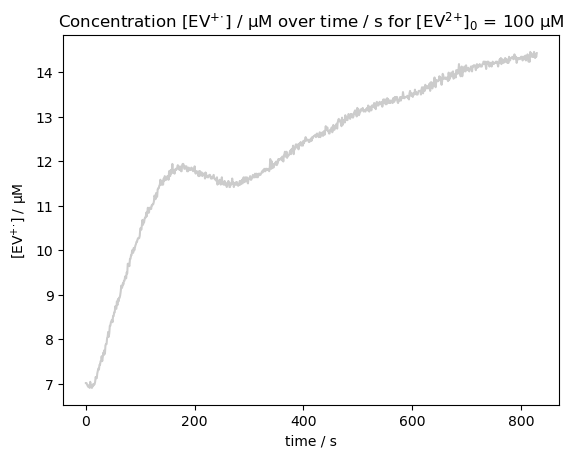

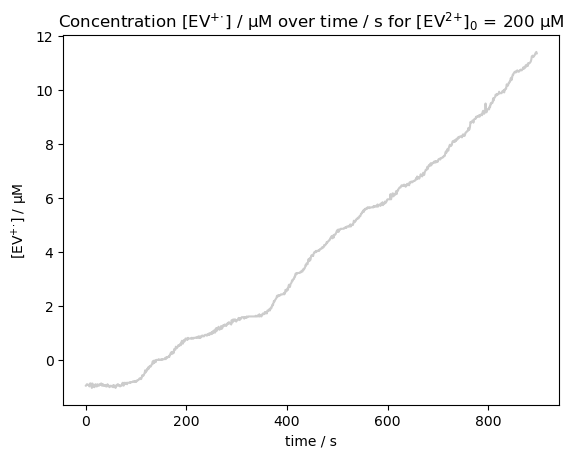

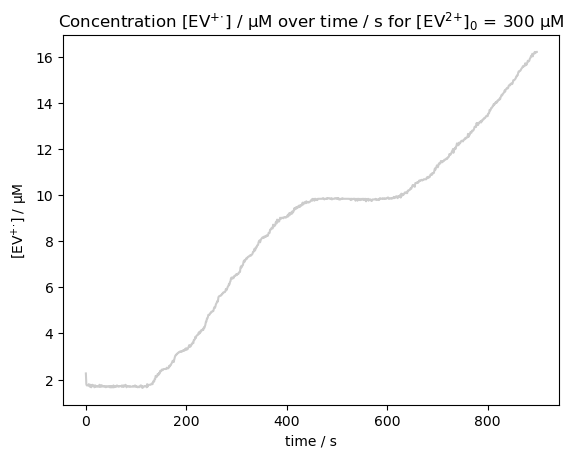

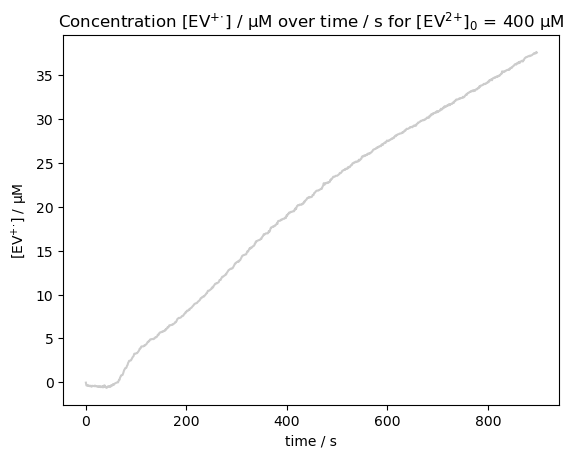

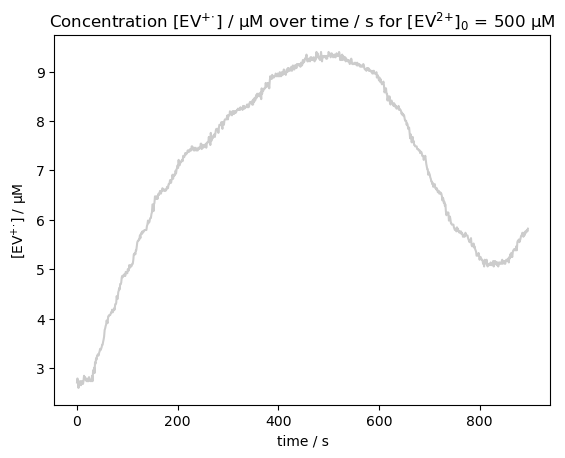

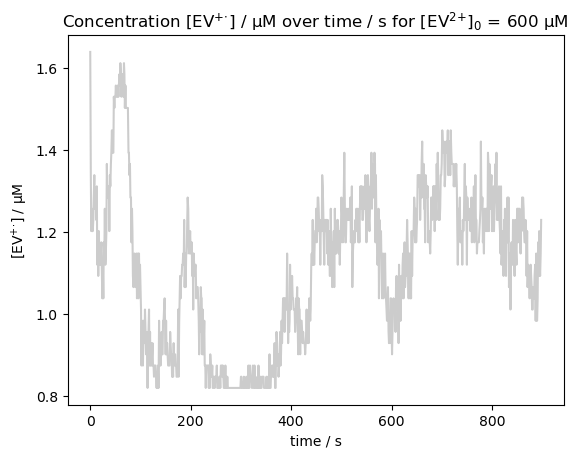

In [6]:
# concentration vs time plot for each run
for (v, start) in runs:
    data = f'{root}/Rubpy_EV_{v}_EDTA'
    c0 = solprop(cstock=cstock, valiquot=v*1e-6, vsol=vsol) # initial XV2+ concentration
    t, c = concvstime(data, peak, e, l, start=start, duration=15*60)
    plt.plot(t, [conc*1e6 for conc in c], color="black", alpha=0.2) # plot time in s, concentrations in μM
    plt.xlabel(r'time / s')
    plt.ylabel(rf'{XV} / μM')
    plt.title(rf'Concentration {XV} / μM over time / s for {XV0} = {c0*1e6:.0f} μM')
    plt.show()

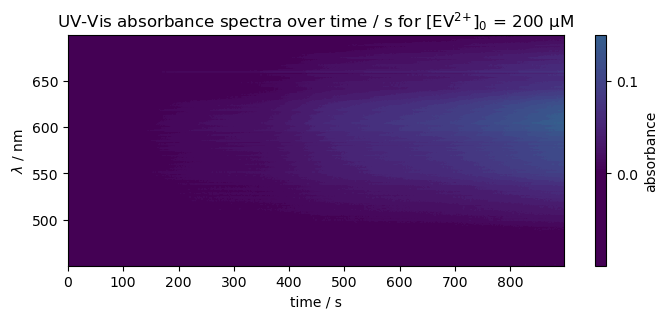

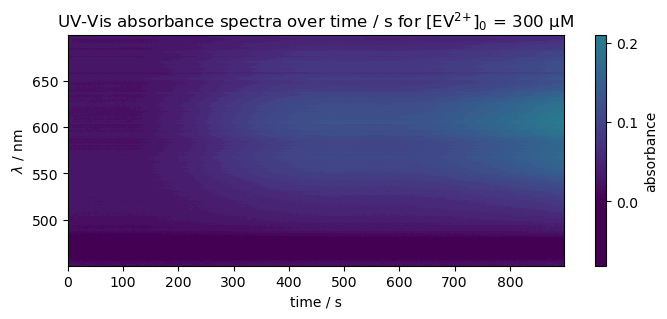

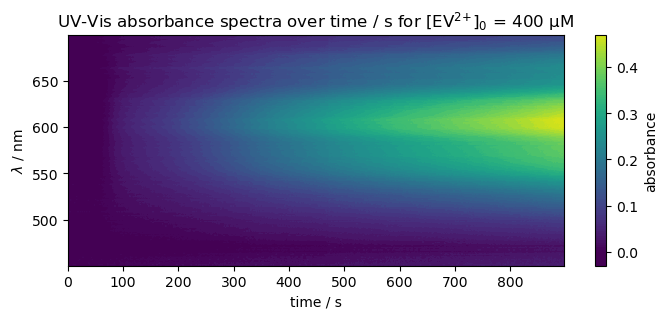

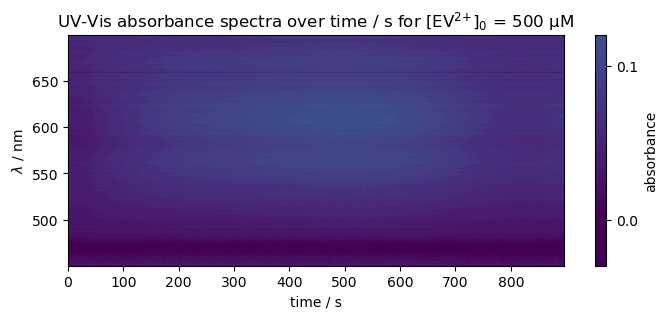

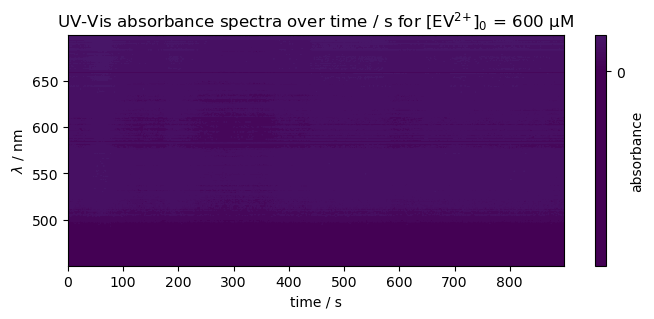

In [7]:
# uv-vis absorption spectrum over time for each run
for (v, start) in runs[1:]: # exclude the run on 260625 which did not include Rubpy in background measurement
    data = f'{root}/Rubpy_EV_{v}_EDTA'
    c0 = solprop(cstock=cstock, valiquot=v*1e-6, vsol=vsol) # initial XV2+ concentration

    t, l, a = spectrumvstime(data, start=start)
    mask = (l >= 450) & (l <= 700) 
    a = a[mask, :]
    l = l[mask]

    fig, ax = plt.subplots(figsize=(8,3))
    cf = ax.contourf(t, l, a, levels=100, vmin=0, vmax=0.5, cmap="viridis")
    ax.set_title(rf"UV-Vis absorbance spectra over time / s for {XV0} = {c0*1e6:.0f} μM")
    ax.set_xlabel("time / s")
    ax.set_ylabel(r'$\lambda$ / nm')
    cbar = plt.colorbar(cf)
    cbar.set_label("absorbance")
    cbar.set_ticks(np.arange(0, a.max(), 0.1))
    plt.show()

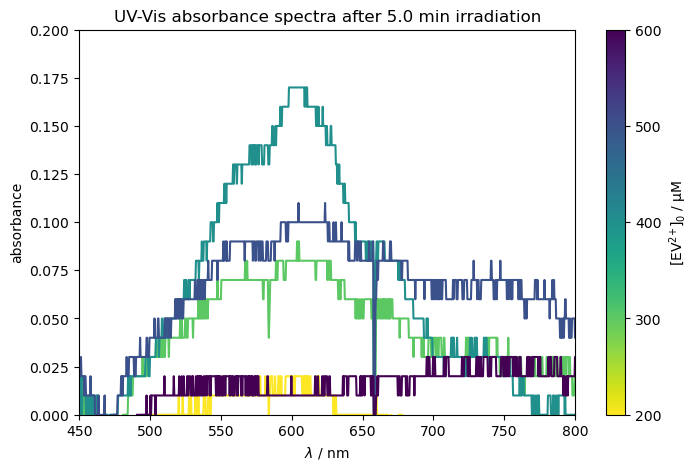

In [8]:
from matplotlib import cm as cm
from matplotlib import colors as colors

# uv-vis absorption spectrum at time t for each run
fig, ax = plt.subplots(figsize=(8,5))
cmap = plt.get_cmap("viridis_r")

t = 5*60
for i, (v, start) in enumerate(runs[1:]): # exclude the run on 260625 which did not include Rubpy in background measurement
    data = f'{root}/Rubpy_EV_{v}_EDTA'
    l, a = spectrumvstimepoints(data, [t], start=start)
    ax.plot(l, a[0], color=cmap(i/(len(runs[1:])-1)))

norm = colors.Normalize(vmin=0, vmax=len(runs[1:])-1)
sm = cm.ScalarMappable(norm=norm, cmap=cmap)
sm.set_array([])
cbar = plt.colorbar(sm, ax=ax)
cbar.set_ticks(range(len(runs[1:])))
cbar.set_ticklabels([f'{solprop(cstock=cstock, valiquot=v*1e-6, vsol=vsol)*1e6:.0f}' for v, _ in runs[1:]])
cbar.set_label(f"{XV0} / μM")

plt.title(f'UV-Vis absorbance spectra after {t/60} min irradiation')
plt.xlim(450, 800)
plt.ylim(0, 0.2)
plt.xlabel(r'$\lambda$ / nm')
plt.ylabel(r'absorbance')
plt.show()